# E-Commerce Revenue Forecasting

## 1. Project Overview

This project builds a revenue forecasting pipeline using the Olist Brazilian e-commerce dataset.

The objective is to predict future monthly revenue by comparing:

1. ARIMA statistical forecasting model
2. XGBoost machine learning forecasting model

The workflow includes:

- Data integration
- Exploratory analysis
- Time-series feature engineering
- Model training
- Forecast evaluation using MAE and RMSE

## 2. Project Workflow

The project follows an end-to-end revenue forecasting pipeline:

```text
                 Data Sources
                      |
                      v
        Orders Dataset + Payments Dataset
                      |
                      v
              Data Integration
          (Merge orders and payments)
                      |
                      v
              Data Exploration
     (Data types, missing values, structure)
                      |
                      v
          Revenue Aggregation
     (Monthly revenue calculation)
                      |
                      v
     Exploratory Time-Series Analysis
        (Revenue trends over time)
                      |
                      v
            Train/Test Split
        (Six-month holdout testing)
                      |
          +-----------+-----------+
          |                       |
          v                       v
   ARIMA Forecasting      XGBoost Forecasting
  (Statistical Model)    (ML + Feature Engineering)
          |                       |
          +-----------+-----------+
                      |
                      v
            Model Evaluation
          (MAE and RMSE)
                      |
                      v
          Feature Importance
      (XGBoost Interpretation)
                      |
                      v
                 Conclusion
      (Best Forecasting Model)
```

## 3. Libraries Used

- Pandas
- NumPy
- Matplotlib
- Statsmodels (ARIMA)
- XGBoost
- Scikit-learn

In [34]:
pip install pandas matplotlib scikit-learn statsmodels xgboost

Note: you may need to restart the kernel to use updated packages.


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

## 4. Load Data

In [36]:
orders = pd.read_csv("olist_orders_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")

In [37]:
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [38]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


## 5. Data Exploration

In [39]:
orders.info()
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  obje

## 6. Missing Value Analysis

In [40]:
orders.isnull().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [41]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

## 7. Revenue Aggregation

In [42]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

df = orders.merge(
    payments,
    on="order_id",
    how="left"
)

In [43]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value'],
      dtype='object')

In [44]:
df["month"] = (
    df["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

In [45]:
df[["order_purchase_timestamp", "month", "payment_value"]].head()

,order_purchase_timestamp,month,payment_value
0,2017-10-02 10:56:33,2017-10,18.12
1,2017-10-02 10:56:33,2017-10,2.00
2,2017-10-02 10:56:33,2017-10,18.59
3,2018-07-24 20:41:37,2018-07,141.46
4,2018-08-08 08:38:49,2018-08,179.12


In [47]:
monthly_revenue = (
    df.groupby("month")["payment_value"]
    .sum()
    .reset_index()
)

monthly_revenue.columns = [
    "month",
    "revenue"
]

monthly_revenue["month"] = pd.to_datetime(
    monthly_revenue["month"]
)

monthly_revenue = monthly_revenue[
    monthly_revenue["month"] < "2018-09-01"
].copy()

monthly_revenue.to_csv(
    "monthly_revenue.csv",
    index=False
)

## 8. Exploratory Time-Series Analysis

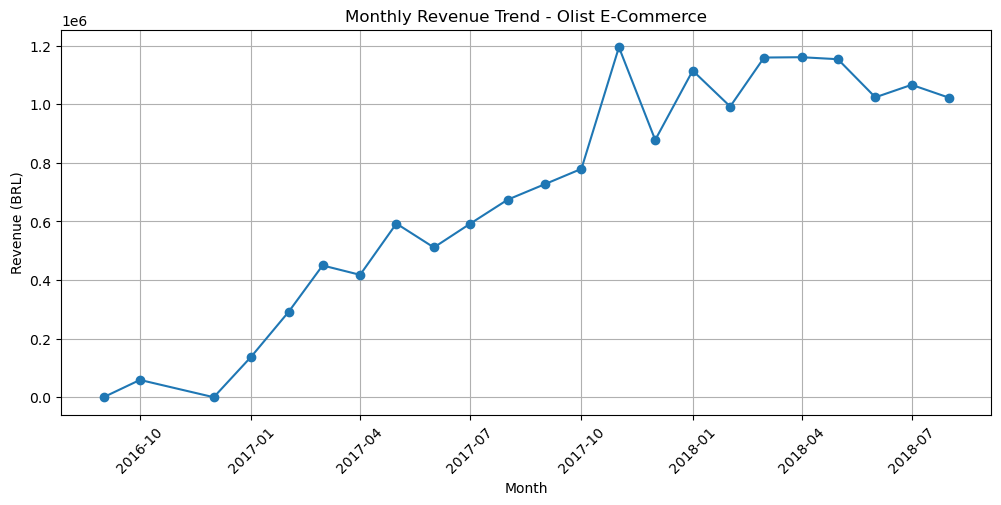

In [48]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.title(
    "Monthly Revenue Trend - Olist E-Commerce"
)

plt.xlabel("Month")
plt.ylabel("Revenue (BRL)")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

## 9. ARIMA Forecasting

In [49]:
arima_data = monthly_revenue.copy()

arima_data["month"] = pd.to_datetime(
    arima_data["month"]
)

arima_data = arima_data.sort_values(
    "month"
)

In [50]:
train = arima_data.iloc[:-6]

test = arima_data.iloc[-6:]

In [51]:
arima_model = ARIMA(
    train["revenue"],
    order=(1,1,1)
)


arima_fit = arima_model.fit()


arima_forecast = arima_fit.forecast(
    steps=6
)

In [52]:
arima_results = test.copy()

arima_results["prediction"] = (
    arima_forecast.values
)


arima_mae = mean_absolute_error(
    arima_results["revenue"],
    arima_results["prediction"]
)


arima_rmse = np.sqrt(
    mean_squared_error(
        arima_results["revenue"],
        arima_results["prediction"]
    )
)


print(
    f"ARIMA MAE: {arima_mae:,.2f}"
)

print(
    f"ARIMA RMSE: {arima_rmse:,.2f}"
)

ARIMA MAE: 49,734.35
ARIMA RMSE: 73,659.58


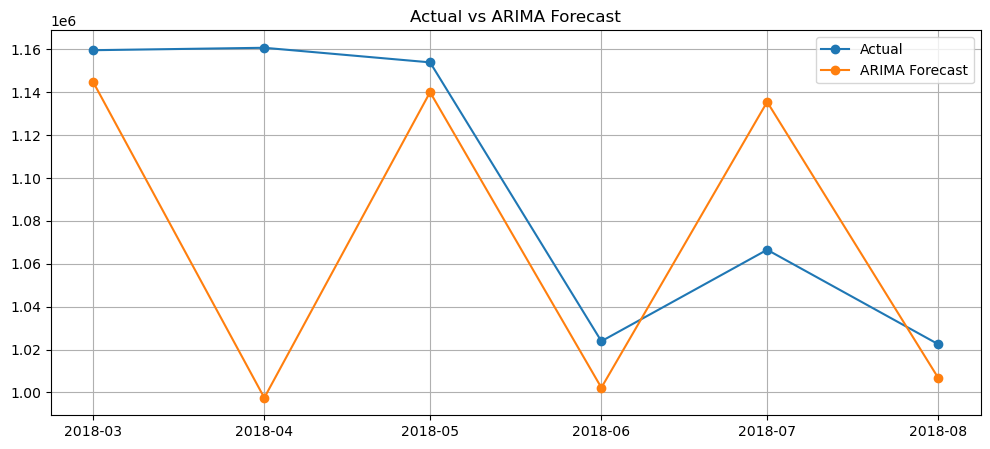

In [53]:
plt.figure(figsize=(12,5))


plt.plot(
    arima_results["month"],
    arima_results["revenue"],
    marker="o",
    label="Actual"
)


plt.plot(
    arima_results["month"],
    arima_results["prediction"],
    marker="o",
    label="ARIMA Forecast"
)


plt.title(
    "Actual vs ARIMA Forecast"
)

plt.legend()
plt.grid(True)

plt.show()

## 10. XGBoost Forecasting

In [54]:
df = monthly_revenue.copy()

df["month"] = pd.to_datetime(df["month"])


df["year"] = df["month"].dt.year

df["month_number"] = df["month"].dt.month

df["quarter"] = df["month"].dt.quarter

In [55]:
df["lag_1"] = df["revenue"].shift(1)

df["lag_2"] = df["revenue"].shift(2)

df["lag_3"] = df["revenue"].shift(3)

df["lag_6"] = df["revenue"].shift(6)

In [56]:
df["rolling_mean_3"] = (
    df["revenue"]
    .shift(1)
    .rolling(3)
    .mean()
)


df["rolling_mean_6"] = (
    df["revenue"]
    .shift(1)
    .rolling(6)
    .mean()
)


df["rolling_std_3"] = (
    df["revenue"]
    .shift(1)
    .rolling(3)
    .std()
)

In [57]:
df = df.dropna()

In [58]:
features = [
    "year",
    "month_number",
    "quarter",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_std_3"
]

In [59]:
train = df.iloc[:-6]

test = df.iloc[-6:]

In [60]:
X_train = train[features]
y_train = train["revenue"]

X_test = test[features]
y_test = test["revenue"]

In [61]:

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.03,
    max_depth=2,
    subsample=0.8,
    random_state=42
)

model.fit(X_train, y_train)
print("XGBoost model trained successfully")

XGBoost model trained successfully


In [62]:
predictions = model.predict(X_test)

forecast_results = test[["month", "revenue"]].copy()
forecast_results["predicted"] = predictions

forecast_results

,month,revenue,predicted
17,2018-03-01,1159652.12,1.075056e+06
18,2018-04-01,1160785.48,9.823818e+05
19,2018-05-01,1153982.15,9.823818e+05
20,2018-06-01,1023880.50,9.823818e+05
21,2018-07-01,1066540.75,1.075056e+06
22,2018-08-01,1022425.32,1.079603e+06


## 11. Model Evaluation

In [63]:

mae = mean_absolute_error(
    forecast_results["revenue"],
    forecast_results["predicted"]
)

rmse = np.sqrt(
    mean_squared_error(
        forecast_results["revenue"],
        forecast_results["predicted"]
    )
)

print(f"XGBoost MAE: {mae:,.2f}")
print(f"XGBoost RMSE: {rmse:,.2f}")

XGBoost MAE: 90,298.60
XGBoost RMSE: 110,675.97


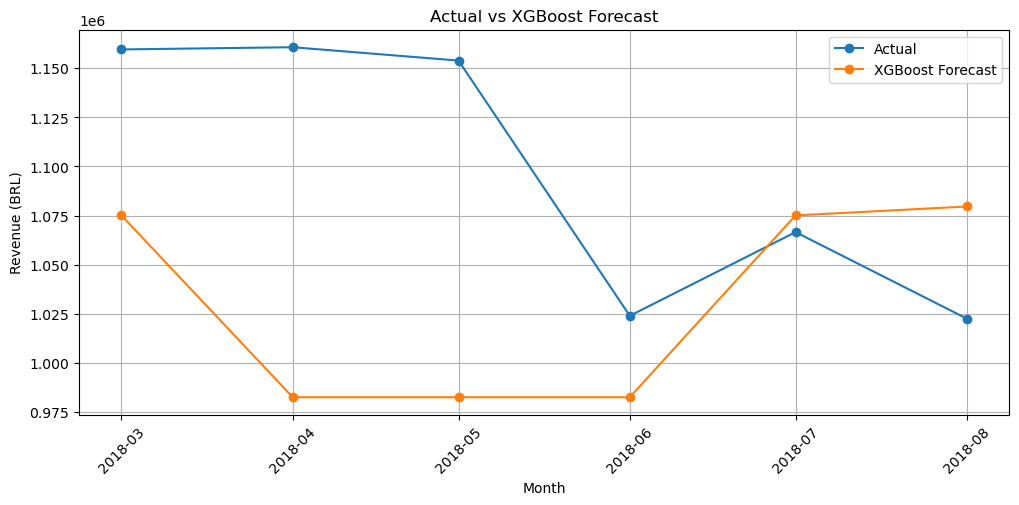

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    forecast_results["month"],
    forecast_results["revenue"],
    marker="o",
    label="Actual"
)

plt.plot(
    forecast_results["month"],
    forecast_results["predicted"],
    marker="o",
    label="XGBoost Forecast"
)

plt.title("Actual vs XGBoost Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue (BRL)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

## 12. Model Comparison

The forecasting models were evaluated using a six-month holdout test set covering March 2018 to August 2018.

| Model | Approach | Features Used | MAE (BRL) | RMSE (BRL) |
|---|---|---|---:|---:|
| ARIMA | Statistical Time-Series Model | Historical revenue values | **49,734.35** | **73,659.58** |
| XGBoost | Machine Learning Model | Time features, lag variables, rolling statistics | **90,298.60** | **110,675.97** |

### Result

ARIMA achieved better forecasting performance compared with XGBoost, reducing:

- MAE by approximately **45%**
- RMSE by approximately **33%**

The stronger performance of ARIMA suggests that the statistical model was better suited to capturing the underlying revenue trend over the six-month evaluation period.

Although XGBoost used additional time-based features, lag variables, and rolling revenue statistics, the relatively small number of monthly observations may have limited its ability to generalise effectively.

The results therefore demonstrate the importance of evaluating both statistical and machine learning models when forecasting business revenue rather than assuming that a more complex machine learning model will necessarily produce better forecasts.

## 13. Feature Importance

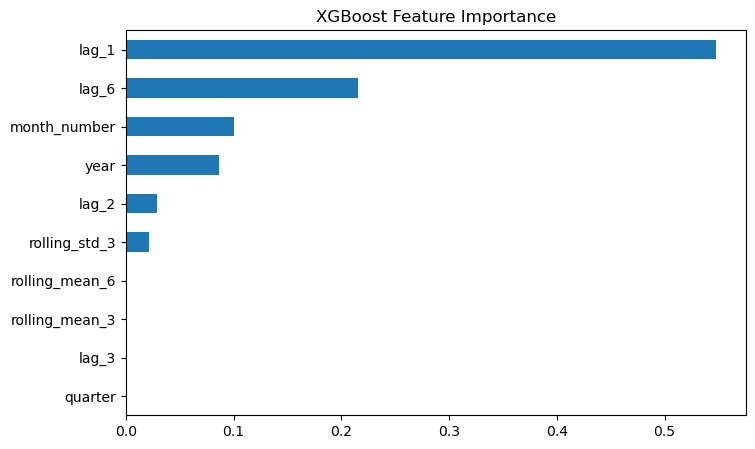

In [65]:
importance = (
    pd.Series(
        model.feature_importances_,
        index=features
    )
    .sort_values()
)

importance.plot(kind="barh", figsize=(8,5))

plt.title("XGBoost Feature Importance")
plt.show()

## 14. Conclusion

**Final Project Summary**

**E-Commerce Revenue Forecasting | Python, Pandas, ARIMA, XGBoost**

Developed an end-to-end revenue forecasting pipeline using the Olist Brazilian e-commerce dataset. Integrated order and payment data, transformed transaction-level records into monthly revenue trends, and performed exploratory time-series analysis.

To avoid evaluating incomplete periods, September and October 2018 were excluded from the analysis. The final six-month holdout test set therefore covered March 2018 to August 2018.

Built and compared ARIMA and XGBoost forecasting models using a six-month holdout test set. Feature engineering for the XGBoost model included time-based variables, lag features, and rolling revenue statistics.

ARIMA achieved the strongest forecasting performance on the test set, with an MAE of 49.7K BRL and an RMSE of 73.7K BRL, outperforming XGBoost, which achieved an MAE of 90.3K BRL and an RMSE of 110.7K BRL.

The results demonstrate the importance of evaluating both statistical and machine learning approaches when forecasting business revenue. While XGBoost provided a flexible feature-based modelling approach, ARIMA performed better for this particular dataset and evaluation period. ARIMA achieved approximately 45% lower MAE and 33% lower RMSE compared with XGBoost.